In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("C:/Users/zinan/OneDrive/Documents/spam email.csv")
df

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
...,...,...
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...


In [2]:
df.shape

(83448, 2)

In [3]:
df.columns

Index(['label', 'text'], dtype='object')

In [4]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [5]:
df.tail()

,label,text
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...
83447,1,get the most out of life ! viagra has helped m...


In [6]:
df.dtypes

label     int64
text     object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [8]:
df.describe()

,label
count,83448.000000
mean,0.526196
std,0.499316
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [9]:
df.isna().sum()

label    0
text     0
dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()
df['text']=lab.fit_transform(df['text'])
df

,label,text
0,1,58703
1,1,80788
2,0,1101
3,1,75357
4,0,69196
...,...,...
83443,0,36997
83444,1,53072
83445,1,22044
83446,0,67389


In [11]:
df1=df['label'].value_counts()
df1

label
1    43910
0    39538
Name: count, dtype: int64

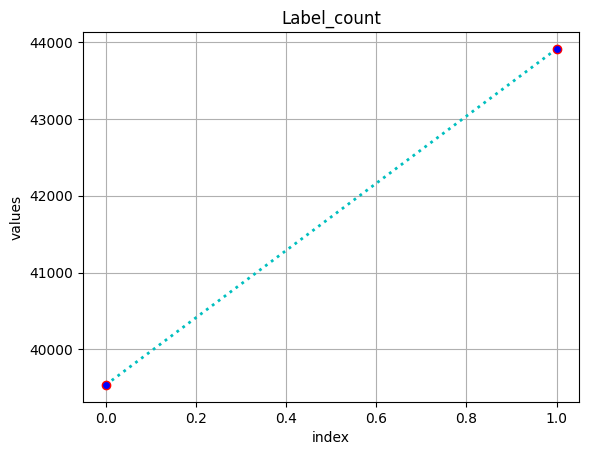

In [12]:
plt.plot(df1.index,df1.values,marker='o',linestyle='dotted',linewidth=2,color='c',ms=6,mec='r',mfc='b')
plt.xlabel('index')
plt.ylabel('values')
plt.title('Label_count')
plt.grid()

Text(20.847222222222214, 0.5, 'Values')

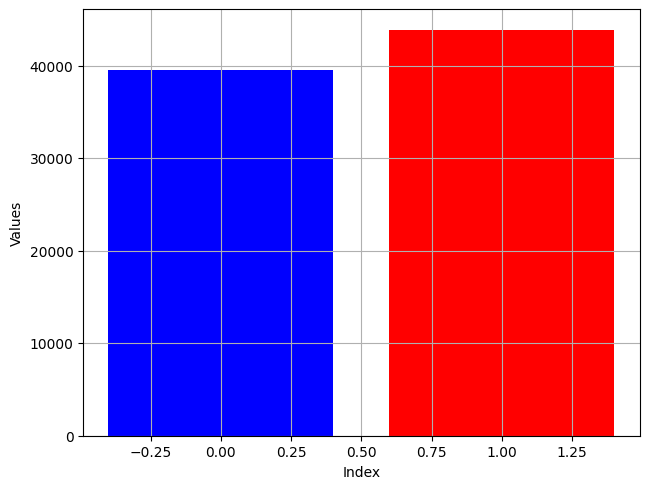

In [13]:
co=['r','b']
plt.bar(df1.index,df1.values,color=co)
plt.grid()
plt.tight_layout()
plt.xlabel('Index')
plt.ylabel('Values')

In [14]:
x=df.iloc[:,-1].values.reshape(-1,1)
y=df.iloc[:,:1].values.flatten()
x

array([[58703],
       [80788],
       [ 1101],
       ...,
       [22044],
       [67389],
       [30480]], shape=(83448, 1))

In [15]:
y

array([1, 1, 0, ..., 1, 0, 1], shape=(83448,))

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=0)
x_train

array([[74687],
       [24800],
       [62505],
       ...,
       [13456],
       [76387],
       [45717]], shape=(58413, 1))

In [17]:
x_test

array([[67934],
       [ 4581],
       [14046],
       ...,
       [51141],
       [40533],
       [44808]], shape=(25035, 1))

In [18]:
y_train

array([0, 1, 1, ..., 0, 0, 0], shape=(58413,))

In [19]:
y_test

array([1, 0, 1, ..., 1, 1, 1], shape=(25035,))

In [20]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(25035,))

In [21]:
y_test

array([1, 0, 1, ..., 1, 1, 1], shape=(25035,))

In [22]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
cm=confusion_matrix(y_test,y_pred)
cm

array([[    0, 11912],
       [    0, 13123]])

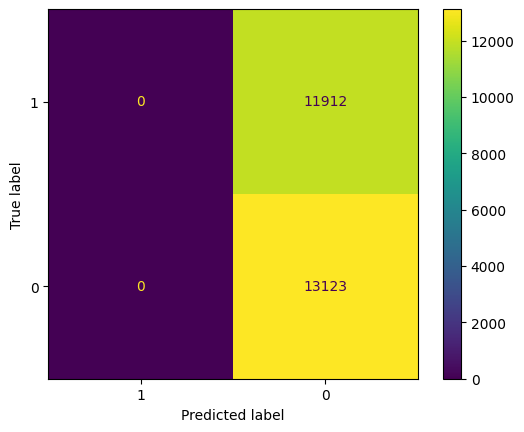

In [23]:
lab=[1,0]
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)
cmd.plot()

In [24]:
score=accuracy_score(y_test,y_pred)*100
score

52.418613940483326

In [25]:
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     11912
           1       0.52      1.00      0.69     13123

    accuracy                           0.52     25035
   macro avg       0.26      0.50      0.34     25035
weighted avg       0.27      0.52      0.36     25035



c:\Users\zinan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zinan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zinan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave